
# 1 &mdash; Squeezing sources: discovery + construction rules

Discovery loop (Sec. 9) run on two gallery targets, followed by the closed-form
recipes of Sec. 7.2:

* **B.1** single-mode squeezer (validation)
* **B.2** EPR / two-mode-squeezed source

AutoGaussian is [AUTOSCATTER](https://github.com/jlandgr/autoscatter)'s discrete +
continuous discovery loop run on a **second-moment** (output covariance) target
$\sigma_\mathrm{out}(\Omega)$ instead of a scattering matrix $S$.

Script version of this notebook: `examples/01_discover_squeezers.py`.

In [1]:
# In case you are using Google Colab, this cell installs AutoGaussian
import sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install "git+https://github.com/Fouriersaur/AutoGaussian.git#subdirectory=autogaussian"
    !pip install cvxpy    # optional: infeasibility certificates (Sec. 6)
else:
    # running from a clone: put the package root on sys.path
    import os
    sys.path.insert(0, os.path.abspath(os.getcwd()))

In [2]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from autogaussian import (
    CovarianceArchitectureOptimizer,
    CovarianceTarget,
    discover,
    plot_list_of_graphs,
    solution_table,
    variance_to_dB,
)
from autogaussian.gallery import epr_source, single_mode_squeezer
from autogaussian.postprocess import symbolic_regression


## B.1 &mdash; single-mode squeezer

$\sigma_\mathrm{target} = \begin{pmatrix} 0.5 & 0 \\ 0 & 2.0\end{pmatrix}$ &mdash;
3 dB of squeezing in $x$, and the conjugate quadrature pinned to $1/v$ so the
emitted state is *pure*.

In [3]:
problem = single_mode_squeezer(variance=0.5)
print(problem.target)

result_smsq = discover(problem.target, num_auxiliary_modes=0, verbose=True,
                       seed=0, **problem.optimizer_kwargs())

CovarianceTarget(single-mode squeezer, 1 ports, 3 pins)
  sigma_out[0,0](Omega=0) = 0.5   (w=1, full)
  sigma_out[0,1](Omega=0) = 0.0   (w=1, full)
  sigma_out[1,1](Omega=0) = 2.0   (w=1, full)


fully connected graph is a valid graph
start breadth-first search over 2 slots (max complexity 3)
test 1 graphs with 3 degrees of freedom:


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 116.63it/s]

test 2 graphs with 2 degrees of freedom:


...

test 2 graphs with 1 degrees of freedom:


  0%|          | 0/2 [00:00<?, ?it/s]

 50%|█████     | 1/2 [00:00<00:00,  1.88it/s]

100%|██████████| 2/2 [00:00<00:00,  3.62it/s]

      certificate fired: passive_range
valid: 3    invalid: 2 (certified 1, uncertified 1)    oracle calls: 33    escalations: 2
optimisation finished, list of irreducible graphs has 2 elements (1 uncertified rejections)
#0  complexity=2  couplings=1  pumps=1
      on-site squeezing 0 (complex)
      loss=3.45e-14  max Re eig(M~)=-0.414
#1  complexity=2  couplings=1  pumps=1
      detuning Delta_0
      on-site squeezing 0 (real)
      loss=1.73e-15  max Re eig(M~)=-0.5
The list of irreducible graphs is complete up to at most 1 false negative (graphs rejected without a certificate):
    [default] on-site squeezing 0 (real)


In [4]:
optimizer = result_smsq["optimizer"]
print(optimizer.report())

#0  complexity=2  couplings=1  pumps=1
      on-site squeezing 0 (complex)
      loss=3.45e-14  max Re eig(M~)=-0.414
#1  complexity=2  couplings=1  pumps=1
      detuning Delta_0
      on-site squeezing 0 (real)
      loss=1.73e-15  max Re eig(M~)=-0.5


The same list with the *solutions* attached &mdash; what a hardware
implementation of each architecture has to dial in (Sec. 8 output).


In [5]:
print(solution_table(optimizer, result_smsq["irreducibles"]))


2 valid graph(s), with the converged parameters:

#0  complexity=2  couplings=1  pumps=1
      on-site squeezing 0 (complex)
      loss=3.45e-14   max Re eig(M~)=-0.4142
      cooperativities:
         C_{0,0}              +0.0294
      phases:
         arg(nu_{0,0})        -1.5708
      decay_ratios:
         kappa~_0             +1.0000

#1  complexity=2  couplings=1  pumps=1
      detuning Delta_0
      on-site squeezing 0 (real)
      loss=1.73e-15   max Re eig(M~)=-0.5000
      cooperativities:
         C_{0,0}              +0.1250
      detunings:
         Delta_0/kappa_0      -0.5303
      decay_ratios:
         kappa~_0             +1.0000



The irreducible devices, drawn as graphs. Black edge = real beam-splitter,
green = complex beam-splitter (synthetic flux), blue = squeezing; a **square**
node carries on-site squeezing and a thick border marks a detuned mode.

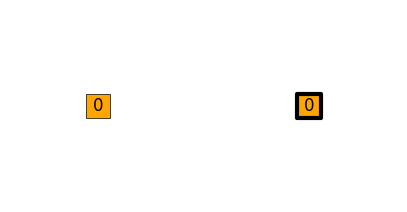

In [6]:
fig, axes = plot_list_of_graphs(result_smsq["irreducibles"], optimizer.space,
                                node_colors=["orange"] * optimizer.space.num_modes)
plt.show()


## Sec. 7.2 &mdash; construction rule $C_{00}(v)$

Sweep the squeezed-quadrature target $v$ over a range and fit the cooperativity
that realises it. The analytic reference is

$$C_{00}(v) = \left(\frac{1-\sqrt{v}}{1+\sqrt{v}}\right)^{2}.$$

In [7]:
v = sp.Symbol("v", positive=True)
target = CovarianceTarget(num_ports=1, name="squeezer with free depth")
target.pin((0, 0), v)          # squeezed quadrature -- the swept parameter
target.pin((1, 1), 1 / v)      # pure state
target.pin((0, 1), 0.0)

optimizer_rules = CovarianceArchitectureOptimizer(
    target, num_auxiliary_modes=0, optimize_gauge=False, make_initial_test=False,
    seed=0)
graph = optimizer_rules.space.empty()
graph[optimizer_rules.space.slots.index(("onsite_squeezing", 0, 0))] = 2

rules = symbolic_regression(optimizer_rules, graph, v, np.linspace(0.05, 0.95, 19))
print("swept %i target values" % len(rules["sweep"]))
for name, (model, expression, rmse) in rules["rules"].items():
    print("   %-14s = %s        [%s, rmse %.1e]" % (name, expression, model, rmse))
print("\n   analytic reference:  C_00(v) = ((1 - sqrt(v)) / (1 + sqrt(v)))^2")

swept 19 target values
   C_{0,0}        = 1.000009*(sqrt(t) - 1.0)**2/(sqrt(t) + 1.000005)**2        [sqrt_rational_squared, rmse 8.9e-08]
   arg(nu_{0,0})  = -1.57079600000000        [quadratic, rmse 2.8e-07]
   kappa~_0       = 1.00000000000000        [constant, rmse 0.0e+00]

   analytic reference:  C_00(v) = ((1 - sqrt(v)) / (1 + sqrt(v)))^2



Fitted rule against the analytic curve:

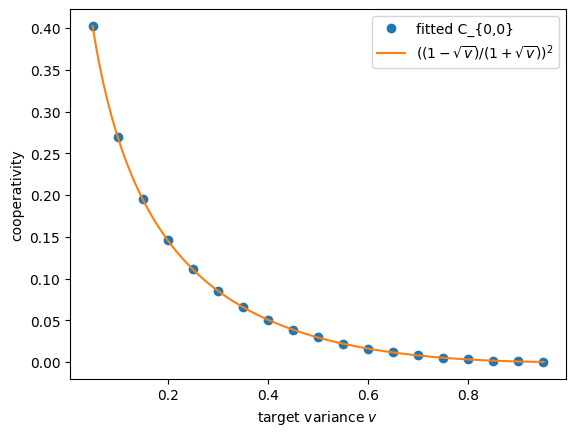

In [8]:
sweep = np.asarray(rules["sweep"], dtype=float)
name = "C_{0,0}"
values = np.asarray(rules["dataset"][name], dtype=float)

grid = np.linspace(0.05, 0.95, 200)
analytic = ((1 - np.sqrt(grid)) / (1 + np.sqrt(grid))) ** 2

plt.plot(sweep, values, "o", label="fitted %s" % name)
plt.plot(grid, analytic, "-", label=r"$((1-\sqrt{v})/(1+\sqrt{v}))^2$")
plt.xlabel(r"target variance $v$")
plt.ylabel("cooperativity")
plt.legend()
plt.show()


## B.2 &mdash; EPR source

Local variance 1.25 at each port and $\pm 0.75$ correlations, i.e. a Duan sum of
1.0 &mdash; well below the separability bound of 2.

In [9]:
problem = epr_source(local=1.25, correlation=0.75)
print(problem.target)

result_epr = discover(problem.target, num_auxiliary_modes=0, verbose=True,
                      seed=2, **problem.optimizer_kwargs())

CovarianceTarget(EPR source, 2 ports, 16 pins)
  sigma_out[0,0](Omega=0) = 1.25   (w=1, full)
  sigma_out[0,1](Omega=0) = 0.0   (w=1, full)
  sigma_out[0,2](Omega=0) = 0.75   (w=1, full)
  sigma_out[0,3](Omega=0) = 0.0   (w=1, full)
  sigma_out[1,0](Omega=0) = 0.0   (w=1, full)
  sigma_out[1,1](Omega=0) = 1.25   (w=1, full)
  sigma_out[1,2](Omega=0) = 0.0   (w=1, full)
  sigma_out[1,3](Omega=0) = -0.75   (w=1, full)
  sigma_out[2,0](Omega=0) = 0.75   (w=1, full)
  sigma_out[2,1](Omega=0) = 0.0   (w=1, full)
  sigma_out[2,2](Omega=0) = 1.25   (w=1, full)
  sigma_out[2,3](Omega=0) = 0.0   (w=1, full)
  sigma_out[3,0](Omega=0) = 0.0   (w=1, full)
  sigma_out[3,1](Omega=0) = -0.75   (w=1, full)
  sigma_out[3,2](Omega=0) = 0.0   (w=1, full)
  sigma_out[3,3](Omega=0) = 1.25   (w=1, full)


fully connected graph is a valid graph
start breadth-first search over 6 slots (max complexity 10)
test 1 graphs with 10 degrees of freedom:


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  1.88it/s]

100%|██████████| 1/1 [00:00<00:00,  1.88it/s]

...

test 3 graphs with 1 degrees of freedom:


  0%|          | 0/3 [00:00<?, ?it/s]

 67%|██████▋   | 2/3 [00:00<00:00, 12.96it/s]

100%|██████████| 3/3 [00:00<00:00, 13.29it/s]

valid: 34    invalid: 122 (certified 1, uncertified 121)    oracle calls: 2462    escalations: 120
optimisation finished, list of irreducible graphs has 3 elements (121 uncertified rejections)
#0  complexity=2  couplings=1  pumps=1
      two-mode squeezing 0-1 (complex)
      loss=8.05e-11  max Re eig(M~)=-0.414
#1  complexity=3  couplings=1  pumps=1
      detuning Delta_0
      detuning Delta_1
      two-mode squeezing 0-1 (real)
      loss=2.37e-12  max Re eig(M~)=-0.5
#2  complexity=3  couplings=3  pumps=2
      beam-splitter 0-1 (real)
      on-site squeezing 0 (real)
      on-site squeezing 1 (real)
      loss=1.38e-11  max Re eig(M~)=-0.5
The list of irreducible graphs is complete up to at most 121 false negatives (graphs rejected without a certificate):
    [default] detuning Delta_1, on-site squeezing 0 (complex), two-mode squeezing 0-1 (real), on-site squeezing 1 (complex)
    [default] beam-splitter 0-1 (complex), detuning Delta_1, two-mode squeezing 0-1 (real), on-site squee

In [10]:
optimizer = result_epr["optimizer"]
best = result_epr["irreducibles"][0]
solution = optimizer.solution_of(best)
V = np.real(optimizer.oracle.covariance(solution["x"], 0.0))

print(", ".join(optimizer.space.describe(best)))
print(np.round(V, 4))

two-mode squeezing 0-1 (complex)
[[ 1.25 -0.    0.75  0.  ]
 [-0.    1.25 -0.   -0.75]
 [ 0.75 -0.    1.25 -0.  ]
 [ 0.   -0.75 -0.    1.25]]


The full search output for B.2: every irreducible architecture with the
cooperativities, pump phases, detunings and decay ratios the oracle converged to.


In [11]:
print(solution_table(optimizer, result_epr["irreducibles"]))


3 valid graph(s), with the converged parameters:

#0  complexity=2  couplings=1  pumps=1
      two-mode squeezing 0-1 (complex)
      loss=8.05e-11   max Re eig(M~)=-0.4142
      cooperativities:
         C^{SQZ}_{0,1}        +0.0294
      phases:
         arg(nu_{0,1})        +1.5708
      decay_ratios:
         kappa~_0             +1.0000
         kappa~_1             +1.0000

#1  complexity=3  couplings=1  pumps=1
      detuning Delta_0
      detuning Delta_1
      two-mode squeezing 0-1 (real)
      loss=2.37e-12   max Re eig(M~)=-0.5000
      cooperativities:
         C^{SQZ}_{0,1}        +6.9339
      phases:
         arg(nu_{0,1})        +3.1416
      detunings:
         Delta_0/kappa_0      -7.6401
         Delta_1/kappa_1      -0.2596
      decay_ratios:
         kappa~_0             +1.0000
         kappa~_1             +1.0000

#2  complexity=3  couplings=3  pumps=2
      beam-splitter 0-1 (real)
      on-site squeezing 0 (real)
      on-site squeezing 1 (real)
      loss=1

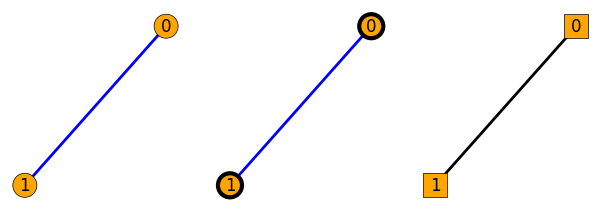

In [12]:
fig, axes = plot_list_of_graphs(result_epr["irreducibles"], optimizer.space,
                                node_colors=["orange"] * optimizer.space.num_modes)
plt.show()


## B.2&prime; &mdash; EPR source with a forbidden port&ndash;port edge (Sec. 7.3)

Same target as B.2, plus one *hardware* constraint: **the two port modes may not
couple to each other**.  This is the covariance analogue of the optomechanical
circulator of [AUTOSCATTER's `6_optomechanical_circulator.ipynb`](https://github.com/jlandgr/autoscatter/blob/main/6_optomechanical_circulator.ipynb)
(Sec. VI of [arXiv:2404.14887](https://arxiv.org/abs/2404.14887)), where the port
modes of a [Bernier *et al.*](https://www.nature.com/articles/s41467-017-00447-1)
style device cannot interact directly and the interaction has to be *mediated* by
a bus mode driven into an asymptotic limit.

In AUTOSCATTER the restriction is `Constraint_coupling_zero(i, j)` plus
`num_far_detuned_modes`.  Here it is a **graph-space restriction**
`forbidden_couplings=[(0, 1)]` &mdash; which kills *both* the beam-splitter and the
two-mode-squeezing slot of the pair, since the Nambu lattice carries two edges per
mode pair &mdash; plus the asymptotic building block
`asymptotic_bus_modes=(2,)`.

First the sanity check: with the edge forbidden and nothing to mediate through,
two ports cannot be correlated at all.


In [13]:
problem = epr_source(local=1.25, correlation=0.75)
kwargs_epr = problem.optimizer_kwargs()

no_mediator = CovarianceArchitectureOptimizer(
    problem.target, num_auxiliary_modes=0,
    forbidden_couplings=[(0, 1)],
    make_initial_test=False, seed=0,
    kwargs_optimization={"num_tests": 20}, **kwargs_epr)

valid, infos = no_mediator.test_graph(no_mediator.space.fully_connected())
print("two ports, no mediator:   valid = %s,  best loss = %.3g"
      % (valid, min(info["loss_reached"] for info in infos)))
print("(the loss floor 1.25 is exactly the pinned correlation block it cannot build)")

two ports, no mediator:   valid = False,  best loss = 1.25
(the loss floor 1.25 is exactly the pinned correlation block it cannot build)



### The asymptotic building block

Mode 2 is declared a **bus**: every coupling touching it is scaled by
$\sqrt{\Lambda}$ per bus endpoint, so a link to a port scales with $\sqrt{\Lambda}$
and a self term with $\Lambda$.  The learnable variables are then the *ratios*
$C_{a b}/\sqrt{C_{bb}}$, which stay finite as $C_\mathrm{bus}\to\infty$; the bus is
only virtually occupied and the residual error of the finite surrogate is
$\sim 1/C_\mathrm{bus}$ (Sec. 7.3).

Two further restrictions keep the lattice at 1458 graphs (~3 min of BFS) and state
the hardware honestly: the ports sit on resonance, and the bus is not pumped
degenerately.  Neither is used by the architectures that come out, but the
completeness claim below is a claim about *this* restricted lattice.


In [14]:
bus_kwargs = dict(
    forbidden_couplings=[(0, 1)],       # the hardware constraint: ports don't touch
    forbidden_detunings=(0, 1),         # ports on resonance
    forbidden_onsite_squeezing=(2,),    # the bus is not degenerately pumped
    asymptotic_bus_modes=(2,),          # mode 2 -> asymptotic building block
    bus_cooperativity=1e6,
)

result_bus = discover(problem.target, num_auxiliary_modes=1, verbose=True, seed=1,
                      kwargs_optimization={"num_tests": 8},
                      **bus_kwargs, **kwargs_epr)

fully connected graph is a valid graph
start breadth-first search over 12 slots (max complexity 13)
test 1 graphs with 13 degrees of freedom:


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  1.84it/s]

100%|██████████| 1/1 [00:00<00:00,  1.84it/s]

test 7 graphs with 12 degrees of freedom:


...

test 4 graphs with 1 degrees of freedom:


  0%|          | 0/4 [00:00<?, ?it/s]

 75%|███████▌  | 3/4 [00:00<00:00, 23.69it/s]

100%|██████████| 4/4 [00:00<00:00, 21.44it/s]

valid: 206    invalid: 442 (certified 1, uncertified 441)    oracle calls: 7545    escalations: 451
optimisation finished, list of irreducible graphs has 2 elements (441 uncertified rejections)
#0  complexity=2  couplings=2  pumps=1
      beam-splitter 1-2 (real)
      two-mode squeezing 0-2 (real)
      loss=5.66e-11  max Re eig(M~)=-0.5
#1  complexity=2  couplings=2  pumps=1
      beam-splitter 0-2 (real)
      two-mode squeezing 1-2 (real)
      loss=1.43e-13  max Re eig(M~)=-0.5
The list of irreducible graphs is complete up to at most 441 false negatives (graphs rejected without a certificate):
    [default] detuning Delta_2, on-site squeezing 0 (complex), two-mode squeezing 0-2 (complex), on-site squeezing 1 (complex), two-mode squeezing 1-2 (complex)
    [default] beam-splitter 1-2 (complex), on-site squeezing 0 (complex), two-mode squeezing 0-2 (complex), on-site squeezing 1 (complex), two-mode squeezing 1-2 (real)
    [default] beam-splitter 1-2 (complex), detuning Delta_2, on-


Two irreducible architectures, mirror images of each other &mdash; exactly the
degenerate pair the circulator notebook finds.  Each uses **two couplings**: a
two-mode-squeezing edge from one port to the bus, and a beam-splitter edge from the
bus to the other port.  The bus converts the squeezing into a correlation between
two modes that never touch.


In [15]:
optimizer_bus = result_bus["optimizer"]
for graph in result_bus["irreducibles"]:
    print(", ".join(optimizer_bus.space.describe(graph)))

best_bus = result_bus["irreducibles"][0]
solution_bus = optimizer_bus.solution_of(best_bus)
V = np.real(optimizer_bus.oracle.covariance(solution_bus["x"], 0.0))[:4, :4]
print("\nsigma_out at the two ports:")
print(np.round(V, 4))

report = optimizer_bus.param.physical_report(solution_bus["x"])
print("\ncooperativities (entries below 1e-6 are graph-reduction residue):")
print({name: "%.4g" % value for name, value in report["cooperativities"].items()
       if value > 1e-6})

beam-splitter 1-2 (real), two-mode squeezing 0-2 (real)
beam-splitter 0-2 (real), two-mode squeezing 1-2 (real)



sigma_out at the two ports:
[[ 1.25 -0.    0.75  0.  ]
 [-0.    1.25 -0.   -0.75]
 [ 0.75 -0.    1.25  0.  ]
 [ 0.   -0.75  0.    1.25]]

cooperativities (entries below 1e-6 are graph-reduction residue):
{'C^{SQZ}_{0,2}': '2.524e+04', 'C^{BS}_{1,2}': '8.573e+05'}


Both bus architectures with the parameters behind them.  These are the
cooperativities of the *finite* surrogate at $C_\mathrm{bus} = 10^6$, so every
coupling that touches the bus carries a factor $\Lambda$; the quantity that stays
finite as $\Lambda \to \infty$ is the ratio $C/C_\mathrm{bus}$ of Sec. 7.3.


In [16]:
print(solution_table(optimizer_bus, result_bus["irreducibles"]))


2 valid graph(s), with the converged parameters:

#0  complexity=2  couplings=2  pumps=1
      beam-splitter 1-2 (real)
      two-mode squeezing 0-2 (real)
      loss=5.66e-11   max Re eig(M~)=-0.5000
      cooperativities:
         C^{SQZ}_{0,2}        +25235.8957
         C^{BS}_{1,2}         +857267.3317
      phases:
         arg(nu_{0,2})        +3.1416
      decay_ratios:
         kappa~_0             +1.0000
         kappa~_1             +1.0000
         kappa~_2             +1.0000

#1  complexity=2  couplings=2  pumps=1
      beam-splitter 0-2 (real)
      two-mode squeezing 1-2 (real)
      loss=1.43e-13   max Re eig(M~)=-0.5000
      cooperativities:
         C^{BS}_{0,2}         +585289.5113
         C^{SQZ}_{1,2}        +17229.3640
      phases:
         arg(g_{0,2})         +3.1416
      decay_ratios:
         kappa~_0             +1.0000
         kappa~_1             +1.0000
         kappa~_2             +1.0000


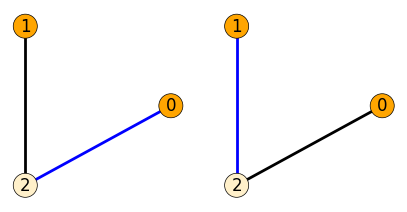

In [17]:
fig, axes = plot_list_of_graphs(result_bus["irreducibles"], optimizer_bus.space,
                                node_colors=["orange", "orange", "#FFF0CA"])
plt.show()


### The limit is real: error $\sim 1/C_\mathrm{bus}$

Hold the converged *ratios* fixed and re-evaluate the device at a finite bus
cooperativity $\Lambda$.  The whole family is one physical device per $\Lambda$
(couplings $\propto\sqrt{\Lambda}$), and the deviation from the EPR target falls off
as $1/\Lambda$ &mdash; the target is met only in the limit.  The curve flattens once it
reaches the residual of the fit itself, which was done at $\Lambda = 10^{6}$.


  C_bus =    1e+01    max |sigma_out - sigma_target| = 8.457e-02
  C_bus =    1e+02    max |sigma_out - sigma_target| = 9.405e-03
  C_bus =    1e+03    max |sigma_out - sigma_target| = 9.465e-04
  C_bus =    1e+04    max |sigma_out - sigma_target| = 9.000e-05
  C_bus =    1e+05    max |sigma_out - sigma_target| = 4.247e-06
  C_bus =    1e+06    max |sigma_out - sigma_target| = 4.330e-06
  C_bus =    1e+07    max |sigma_out - sigma_target| = 5.188e-06
  C_bus =    1e+08    max |sigma_out - sigma_target| = 5.274e-06


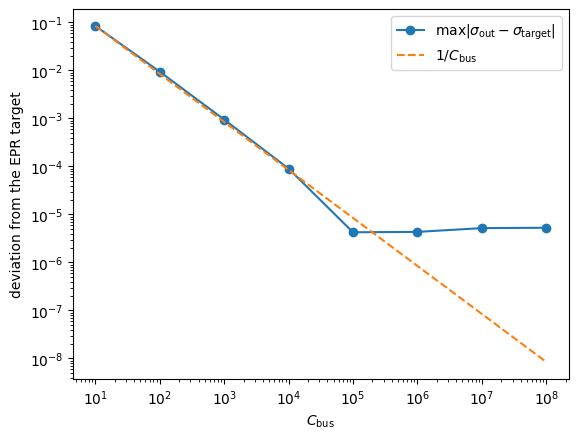

In [18]:
local, correlation = 1.25, 0.75
target_V = np.array([[local, 0.0, correlation, 0.0],
                     [0.0, local, 0.0, -correlation],
                     [correlation, 0.0, local, 0.0],
                     [0.0, -correlation, 0.0, local]])

lambdas = np.logspace(1, 8, 8)
errors = []
for bus_cooperativity in lambdas:
    surrogate = CovarianceArchitectureOptimizer(
        problem.target, num_auxiliary_modes=1, make_initial_test=False,
        **dict(bus_kwargs, bus_cooperativity=bus_cooperativity), **kwargs_epr)
    V_finite = np.real(surrogate.oracle.covariance(solution_bus["x"], 0.0))[:4, :4]
    errors.append(np.abs(V_finite - target_V).max())

for bus_cooperativity, error in zip(lambdas, errors):
    print("  C_bus = %8.0e    max |sigma_out - sigma_target| = %.3e"
          % (bus_cooperativity, error))

plt.loglog(lambdas, errors, "o-", label=r"$\max|\sigma_\mathrm{out}-\sigma_\mathrm{target}|$")
plt.loglog(lambdas, errors[0] * lambdas[0] / lambdas, "--", label=r"$1/C_\mathrm{bus}$")
plt.xlabel(r"$C_\mathrm{bus}$")
plt.ylabel("deviation from the EPR target")
plt.legend()
plt.show()


### What the asymptotic block buys, and what it does not

Drop the block and re-fit the *same* two-coupling architecture with ordinary,
unscaled variables.  It still converges &mdash; by running the cooperativities up to
$\sim10^{5}$.  That is the same asymptotic manifold reached by brute force, badly
conditioned: `asymptotic_bus_modes` does not add solutions, it makes the limit point
*representable*, so the search can find the minimal architectures instead of chasing
runaway couplings.


In [19]:
finite = CovarianceArchitectureOptimizer(
    problem.target, num_auxiliary_modes=1,
    forbidden_couplings=[(0, 1)], forbidden_detunings=(0, 1),
    forbidden_onsite_squeezing=(2,),
    make_initial_test=False, seed=5,
    kwargs_optimization={"num_tests": 30, "max_violation_success": 1e-12},
    **kwargs_epr)

valid, infos = finite.test_graph(best_bus)
info = min(infos, key=lambda item: item["loss_reached"])
print("same graph, no asymptotic block:  valid = %s,  loss = %.3g"
      % (valid, info["loss_reached"]))
print({name: "%.4g" % value
       for name, value in finite.param.physical_report(info["x"])["cooperativities"].items()})

same graph, no asymptotic block:  valid = True,  loss = 7.49e-13
{'C^{SQZ}_{0,2}': '7296', 'C^{BS}_{1,2}': '2.478e+05'}



The honest caveat, and the difference from the circulator: the mediation
restriction alone does **not** push this target onto the asymptotic manifold.  Give
the search its full element budget back &mdash; port detunings and a degenerate pump
on the mediator &mdash; and a *resonant* auxiliary mode reaches the same pure EPR
state at cooperativities of order one, using seven elements instead of two.  The
asymptotic block is what you need when the minimal, two-coupling architecture is the
one you want, or when the hardware forces the mediator far off resonance.


In [20]:
resonant = CovarianceArchitectureOptimizer(
    problem.target, num_auxiliary_modes=1, forbidden_couplings=[(0, 1)],
    make_initial_test=False, seed=1,
    kwargs_optimization={"num_tests": 20, "max_violation_success": 1e-12},
    **kwargs_epr)

valid, infos = resonant.test_graph(resonant.space.fully_connected())
info = min(infos, key=lambda item: item["loss_reached"])
print("resonant mediator, full element budget:  valid = %s,  loss = %.3g"
      % (valid, info["loss_reached"]))
print({name: "%.3g" % value
       for name, value in resonant.param.physical_report(info["x"])["cooperativities"].items()})

resonant mediator, full element budget:  valid = True,  loss = 9.29e-13
{'C_{0,0}': '0.724', 'C^{BS}_{0,2}': '4.12', 'C^{SQZ}_{0,2}': '3.75', 'C_{1,1}': '0.682', 'C^{BS}_{1,2}': '4.22', 'C^{SQZ}_{1,2}': '2.4', 'C_{2,2}': '0.939'}
